# 全体像

仮想データで品質推定を試す。latent、direct、fusionを比べる。


## 1. ライブラリ

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

## 2. パラメータ

In [2]:
SEED = 42

T = 12000
M = 30
delay = 8

L = 64
Lq = 64

z_dim = 48
batch_size_1 = 256
batch_size_q = 32

epochs_1 = 80
epochs_q = 200

lr_1 = 1e-3
lr_q = 5e-4

patience_1 = 12
patience_q = 30

train_ratio = 0.60
val_ratio = 0.20

model1_hidden = 96
quality_hidden = 64
quality_dropout = 0.30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("device:", device)


device: cuda


## 3. 関数

In [3]:
def causal_moving_average(a, w):
    a = np.asarray(a, dtype=np.float32)
    out = np.empty_like(a, dtype=np.float32)
    c = np.cumsum(np.insert(a, 0, 0.0))
    for t in range(len(a)):
        s = max(0, t - w + 1)
        out[t] = (c[t + 1] - c[s]) / (t - s + 1)
    return out

def standardize_train(A, train_end):
    mean = A[:train_end].mean(axis=0, keepdims=True)
    std = A[:train_end].std(axis=0, keepdims=True) + 1e-8
    return ((A - mean) / std).astype(np.float32), mean.astype(np.float32), std.astype(np.float32)

def standardize_by_train_values(y, train_mask):
    mean = y[train_mask].mean()
    std = y[train_mask].std() + 1e-8
    yn = ((y - mean) / std).astype(np.float32)
    return yn, float(mean), float(std)

def unstandardize(y, mean, std):
    return y * std + mean

def make_time_split_mask(times, train_end, val_end):
    train_mask = times < train_end
    val_mask = (times >= train_end) & (times < val_end)
    test_mask = times >= val_end
    return train_mask, val_mask, test_mask

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))


## 4. 産業プロセスシミュレーター

高頻度で得られるセンサデータ `X` と操作入力 `U` を作る。真の品質 `q_true` は、カンニングさせないように注意。

In [4]:
def simulate_process(T=12000, seed=42):
    rng = np.random.default_rng(seed)

    U = np.zeros((T, 2), dtype=np.float32)
    X = np.zeros((T, 4), dtype=np.float32)

    U[0] = np.array([0.0, 0.0], dtype=np.float32)
    X[0] = np.array([55.0, 1.05, 1.00, 1.00], dtype=np.float32)

    sp_temp = 58.0 + 3.0 * np.sin(np.linspace(0, 5.5 * np.pi, T))
    sp_conc = 1.10 + 0.08 * np.sin(np.linspace(0, 4.0 * np.pi, T) + 1.0)

    for t in range(1, T):
        if t % 400 == 0:
            U[t, 0] = U[t - 1, 0] + rng.normal(0, 0.8)
            U[t, 1] = U[t - 1, 1] + rng.normal(0, 0.4)
        else:
            U[t, 0] = 0.995 * U[t - 1, 0] + rng.normal(0, 0.02)
            U[t, 1] = 0.995 * U[t - 1, 1] + rng.normal(0, 0.01)

        U[t, 0] = np.clip(U[t, 0], -3.0, 3.0)
        U[t, 1] = np.clip(U[t, 1], -2.0, 2.0)

    for t in range(1, T):
        temp, conc, press, visc = X[t - 1]

        pulse = 0.0
        if rng.random() < 0.004:
            pulse = rng.normal(0, 3.0)

        temp_target = sp_temp[t] + 0.9 * U[t, 0] - 1.5 * U[t, 1]
        conc_target = sp_conc[t] + 0.06 * U[t, 1] - 0.02 * U[t, 0]
        press_target = 1.00 + 0.10 * U[t, 1] + 0.015 * (temp - 58.0)
        visc_target = 1.00 + 0.55 * (conc - 1.1) - 0.012 * (temp - 58.0)

        X[t, 0] = temp + 0.035 * (temp_target - temp) + rng.normal(0, 0.20) + pulse
        X[t, 1] = conc + 0.045 * (conc_target - conc) + rng.normal(0, 0.008)
        X[t, 2] = press + 0.060 * (press_target - press) + rng.normal(0, 0.006)
        X[t, 3] = visc + 0.040 * (visc_target - visc) + rng.normal(0, 0.010)

    for _ in range(max(1, T // 450)):
        t = rng.integers(100, T - 10)
        j = rng.integers(0, 4)
        length = rng.integers(1, 5)
        amp = rng.normal(0, [5.0, 0.08, 0.06, 0.08][j])
        X[t:t + length, j] += amp

    temp_ma45 = causal_moving_average(X[:, 0], 45)
    conc_ma35 = causal_moving_average(X[:, 1], 35)
    press_ma25 = causal_moving_average(X[:, 2], 25)
    visc_ma60 = causal_moving_average(X[:, 3], 60)

    q_true = (
        93.0
        + 0.22 * (temp_ma45 - 58.0)
        + 4.0 * (conc_ma35 - 1.10)
        - 2.5 * (press_ma25 - 1.00)
        + 1.8 * (visc_ma60 - 1.00)
        + 0.35 * np.sin(np.linspace(0, 3.0 * np.pi, T))
    ).astype(np.float32)

    return X.astype(np.float32), U.astype(np.float32), q_true.astype(np.float32)


## 5. データ生成 & 下処理

In [5]:
X_raw, U_raw, q_true = simulate_process(T=T, seed=SEED)

train_end = int(train_ratio * T)
val_end = int((train_ratio + val_ratio) * T)

X, x_mean, x_std = standardize_train(X_raw, train_end)
U, u_mean, u_std = standardize_train(U_raw, train_end)

print("X_raw:", X_raw.shape, "U_raw:", U_raw.shape, "q_true:", q_true.shape)
print("train_end:", train_end, "val_end:", val_end)


X_raw: (12000, 4) U_raw: (12000, 2) q_true: (12000,)
train_end: 7200 val_end: 9600


## 6. 低頻度・遅延品質データ

品質ラベルは低頻度で、少し遅れて届く設定である。


In [6]:
rng = np.random.default_rng(SEED + 1)

min_time = max(L, Lq, 128)
feature_times = np.arange(min_time, T - delay, M, dtype=int)
measurement_times = feature_times + delay

q_obs = q_true[feature_times] + rng.normal(0.0, 0.75, size=len(feature_times)).astype(np.float32)

outlier_mask = rng.random(len(q_obs)) < 0.05
q_obs[outlier_mask] += rng.normal(0.0, 2.0, size=outlier_mask.sum()).astype(np.float32)

train_q_mask, val_q_mask, test_q_mask = make_time_split_mask(feature_times, train_end, val_end)
q_obs_norm, q_mean, q_std = standardize_by_train_values(q_obs, train_q_mask)

print("quality labels:", len(q_obs))
print("train/val/test labels:", train_q_mask.sum(), val_q_mask.sum(), test_q_mask.sum())
print("q_mean:", q_mean, "q_std:", q_std)


quality labels: 396
train/val/test labels: 236 80 80
q_mean: 93.1030044555664 q_std: 1.134434700012207


## 7. シミュレーター確認用プロット

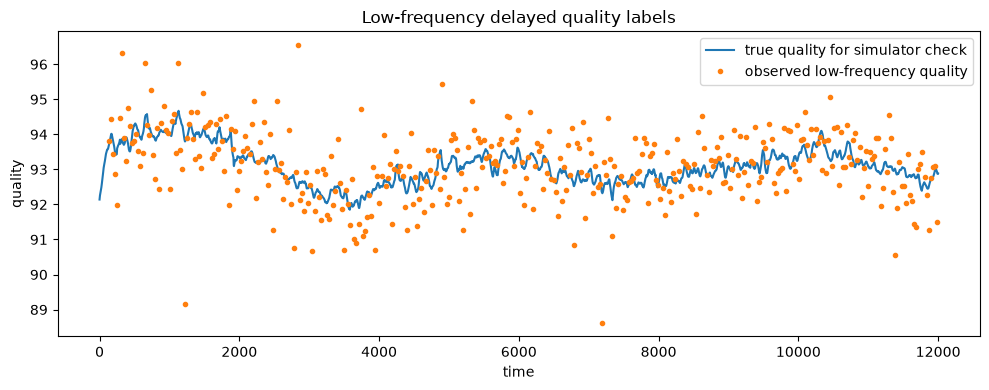

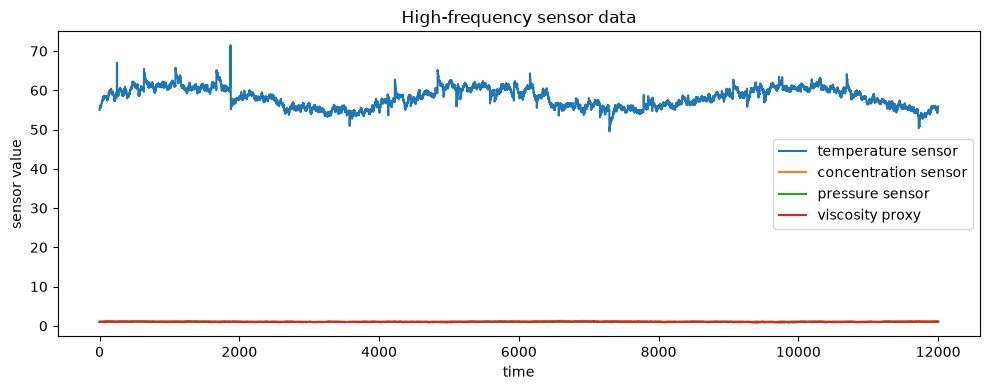

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(T), q_true, label="true quality")
plt.plot(measurement_times, q_obs, "o", markersize=3, label="observed quality")
plt.title("Low-frequency delayed quality labels")
plt.xlabel("time")
plt.ylabel("quality")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(np.arange(T), X_raw[:, 0], label="temperature")
plt.plot(np.arange(T), X_raw[:, 1], label="concentration")
plt.plot(np.arange(T), X_raw[:, 2], label="pressure")
plt.plot(np.arange(T), X_raw[:, 3], label="viscosity proxy")
plt.title("High-frequency sensor data")
plt.xlabel("time")
plt.ylabel("sensor value")
plt.legend()
plt.tight_layout()
plt.show()


## 8. model_1 用 Dataset

過去のセンサと操作入力から、次のセンサを予測する。


In [8]:
class NextSensorDataset(Dataset):
    def __init__(self, X, U, start_t, end_t, L):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.U = torch.tensor(U, dtype=torch.float32)
        self.times = np.arange(max(start_t, L), end_t, dtype=int)
        self.L = L

    def __len__(self):
        return len(self.times)

    def __getitem__(self, i):
        t = self.times[i]
        x_seq = self.X[t - self.L:t]
        u_seq = self.U[t - self.L:t]
        y = self.X[t]
        return x_seq, u_seq, y

train_1_loader = DataLoader(
    NextSensorDataset(X, U, L, train_end, L),
    batch_size=batch_size_1,
    shuffle=True,
    drop_last=False,
)

val_1_loader = DataLoader(
    NextSensorDataset(X, U, train_end, val_end, L),
    batch_size=batch_size_1,
    shuffle=False,
    drop_last=False,
)


## 9. model_1

encoderでlatentを作り、センサの変化量を予測する。


In [9]:
class ResidualLatentDynamicsModel(nn.Module):
    def __init__(self, x_dim, u_dim, z_dim=48, hidden=96, dropout=0.10):
        super().__init__()

        self.encoder = nn.GRU(
            input_size=x_dim + u_dim,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
        )

        self.to_z = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, z_dim),
        )

        self.transition = nn.Sequential(
            nn.LayerNorm(z_dim + u_dim),
            nn.Linear(z_dim + u_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, z_dim),
        )

        self.decoder = nn.Sequential(
            nn.LayerNorm(z_dim),
            nn.Linear(z_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, x_dim),
        )

    def encode(self, x_seq, u_seq):
        seq = torch.cat([x_seq, u_seq], dim=-1)
        h, _ = self.encoder(seq)
        z = self.to_z(h[:, -1, :])
        return z

    def forward(self, x_seq, u_seq):
        z = self.encode(x_seq, u_seq)
        u_last = u_seq[:, -1, :]
        dz = self.transition(torch.cat([z, u_last], dim=-1))
        z_next = z + dz

        x_last = x_seq[:, -1, :]
        dx = self.decoder(z_next)
        x_next_hat = x_last + dx
        return x_next_hat, z_next

model_1 = ResidualLatentDynamicsModel(
    x_dim=X.shape[1],
    u_dim=U.shape[1],
    z_dim=z_dim,
    hidden=model1_hidden,
    dropout=0.10,
).to(device)

loss_fn_1 = nn.MSELoss()

def evaluate_model_1(model, loader):
    model.eval()
    total = 0.0
    count = 0

    with torch.no_grad():
        for x_seq, u_seq, y in loader:
            x_seq = x_seq.to(device)
            u_seq = u_seq.to(device)
            y = y.to(device)

            pred, _ = model(x_seq, u_seq)
            loss = loss_fn_1(pred, y)

            total += loss.item() * len(y)
            count += len(y)

    return total / max(count, 1)

def train_model_1(model, train_loader, val_loader, epochs=80, lr=1e-3, patience=12):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    history = {"train": [], "val": []}
    best_state = None
    best_val = np.inf
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        count = 0

        for x_seq, u_seq, y in train_loader:
            x_seq = x_seq.to(device)
            u_seq = u_seq.to(device)
            y = y.to(device)

            pred, _ = model(x_seq, u_seq)
            loss = loss_fn_1(pred, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total += loss.item() * len(y)
            count += len(y)

        train_loss = total / max(count, 1)
        val_loss = evaluate_model_1(model, val_loader)
        scheduler.step(val_loss)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"model_1 epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

        if wait >= patience:
            print(f"model_1 early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

print("\nTrain model_1")
history_1 = train_model_1(
    model_1,
    train_1_loader,
    val_1_loader,
    epochs=epochs_1,
    lr=lr_1,
    patience=patience_1,
)

def persistence_loss(loader):
    total = 0.0
    count = 0
    with torch.no_grad():
        for x_seq, u_seq, y in loader:
            pred = x_seq[:, -1, :]
            loss = loss_fn_1(pred, y)
            total += loss.item() * len(y)
            count += len(y)
    return total / max(count, 1)

print("model_1 val loss:", evaluate_model_1(model_1, val_1_loader))
print("persistence val loss:", persistence_loss(val_1_loader))



Train model_1
model_1 epoch 001 | train 0.0320 | val 0.0238
model_1 epoch 010 | train 0.0257 | val 0.0233
model_1 epoch 020 | train 0.0253 | val 0.0233
model_1 early stopping at epoch 25
model_1 val loss: 0.02322240486741066
persistence val loss: 0.023553231755892436


## 10. 潜在状態 Z の計算

学習済み `model_1` を使って、各時刻の潜在状態 `Z` を作る。

In [10]:
@torch.no_grad()
def compute_latents(model, X, U, L, batch_size=512):
    model.eval()
    Z = np.full((len(X), model.to_z[-1].out_features), np.nan, dtype=np.float32)

    indices = np.arange(L - 1, len(X), dtype=int)

    for s in range(0, len(indices), batch_size):
        batch_idx = indices[s:s + batch_size]

        x_seqs = []
        u_seqs = []
        for t in batch_idx:
            x_seqs.append(X[t - L + 1:t + 1])
            u_seqs.append(U[t - L + 1:t + 1])

        x_seqs = torch.tensor(np.stack(x_seqs), dtype=torch.float32, device=device)
        u_seqs = torch.tensor(np.stack(u_seqs), dtype=torch.float32, device=device)

        z = model.encode(x_seqs, u_seqs).detach().cpu().numpy()
        Z[batch_idx] = z

    return Z

Z = compute_latents(model_1, X, U, L)
Z0 = np.nan_to_num(Z, nan=0.0).astype(np.float32)

print("Z:", Z.shape)
print("Z finite ratio:", np.isfinite(Z).mean())


Z: (12000, 48)
Z finite ratio: 0.99475


## 11. model_2 用 Dataset

latent、生センサ、両方を使う入力を作る。


In [11]:
A_latent = np.concatenate([Z0, U], axis=1).astype(np.float32)
A_direct = np.concatenate([X, U], axis=1).astype(np.float32)
A_fusion = np.concatenate([X, Z0, U], axis=1).astype(np.float32)

print("A_latent:", A_latent.shape)
print("A_direct:", A_direct.shape)
print("A_fusion:", A_fusion.shape)

class QualitySequenceDataset(Dataset):
    def __init__(self, A, feature_times, y, mask, Lq):
        self.A = torch.tensor(A, dtype=torch.float32)
        self.feature_times = np.asarray(feature_times[mask], dtype=int)
        self.y = torch.tensor(y[mask], dtype=torch.float32)
        self.Lq = Lq

    def __len__(self):
        return len(self.feature_times)

    def __getitem__(self, i):
        t = self.feature_times[i]
        seq = self.A[t - self.Lq + 1:t + 1]
        return seq, self.y[i]

def make_quality_loaders(A):
    train_loader = DataLoader(
        QualitySequenceDataset(A, feature_times, q_obs_norm, train_q_mask, Lq),
        batch_size=batch_size_q,
        shuffle=True,
        drop_last=False,
    )

    val_loader = DataLoader(
        QualitySequenceDataset(A, feature_times, q_obs_norm, val_q_mask, Lq),
        batch_size=batch_size_q,
        shuffle=False,
        drop_last=False,
    )

    test_loader = DataLoader(
        QualitySequenceDataset(A, feature_times, q_obs_norm, test_q_mask, Lq),
        batch_size=batch_size_q,
        shuffle=False,
        drop_last=False,
    )

    return train_loader, val_loader, test_loader

train_latent_loader, val_latent_loader, test_latent_loader = make_quality_loaders(A_latent)
train_direct_loader, val_direct_loader, test_direct_loader = make_quality_loaders(A_direct)
train_fusion_loader, val_fusion_loader, test_fusion_loader = make_quality_loaders(A_fusion)


A_latent: (12000, 50)
A_direct: (12000, 6)
A_fusion: (12000, 54)


## 12. model_2, direct_model, fusion_model

attention付きGRUで3種類の入力を比べる。


In [12]:
class QualityGRU(nn.Module):
    def __init__(self, input_dim, hidden=64, dropout=0.30):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
        )

        self.attn = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.Tanh(),
            nn.Linear(hidden // 2, 1),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, seq):
        h, _ = self.gru(seq)

        weight = torch.softmax(self.attn(h), dim=1)
        context = (weight * h).sum(dim=1)

        y = self.head(context).squeeze(-1)
        return y

model_2 = QualityGRU(
    input_dim=A_latent.shape[1],
    hidden=quality_hidden,
    dropout=quality_dropout,
).to(device)

direct_model = QualityGRU(
    input_dim=A_direct.shape[1],
    hidden=quality_hidden,
    dropout=quality_dropout,
).to(device)

fusion_model = QualityGRU(
    input_dim=A_fusion.shape[1],
    hidden=quality_hidden,
    dropout=quality_dropout,
).to(device)

loss_fn_q = nn.SmoothL1Loss(beta=0.5)

def evaluate_regressor(model, loader):
    model.eval()
    total = 0.0
    count = 0

    with torch.no_grad():
        for seq, y in loader:
            seq = seq.to(device)
            y = y.to(device)

            pred = model(seq)
            loss = loss_fn_q(pred, y)

            total += loss.item() * len(y)
            count += len(y)

    return total / max(count, 1)

def train_regressor(model, train_loader, val_loader, epochs=200, lr=5e-4, patience=30):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=3e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=8,
    )

    history = {"train": [], "val": []}
    best_state = None
    best_val = np.inf
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        count = 0

        for seq, y in train_loader:
            seq = seq.to(device)
            y = y.to(device)

            pred = model(seq)
            loss = loss_fn_q(pred, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total += loss.item() * len(y)
            count += len(y)

        train_loss = total / max(count, 1)
        val_loss = evaluate_regressor(model, val_loader)
        scheduler.step(val_loss)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 20 == 0:
            print(f"epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

        if wait >= patience:
            print(f"early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


## 13. 品質モデルの学習

外れ値もあるので `SmoothL1Loss` を使う。


In [13]:
print("\nTrain model_2 latent soft sensor")
history_2 = train_regressor(
    model_2,
    train_latent_loader,
    val_latent_loader,
    epochs=epochs_q,
    lr=lr_q,
    patience=patience_q,
)

print("\nTrain direct baseline")
history_direct = train_regressor(
    direct_model,
    train_direct_loader,
    val_direct_loader,
    epochs=epochs_q,
    lr=lr_q,
    patience=patience_q,
)

print("\nTrain fusion soft sensor")
history_fusion = train_regressor(
    fusion_model,
    train_fusion_loader,
    val_fusion_loader,
    epochs=epochs_q,
    lr=lr_q,
    patience=patience_q,
)

print("\nnormalized test loss")
print("model_2 latent:", evaluate_regressor(model_2, test_latent_loader))
print("direct        :", evaluate_regressor(direct_model, test_direct_loader))
print("fusion        :", evaluate_regressor(fusion_model, test_fusion_loader))



Train model_2 latent soft sensor
epoch 001 | train 0.5628 | val 0.3105


epoch 020 | train 0.4305 | val 0.3275
early stopping at epoch 33

Train direct baseline
epoch 001 | train 0.5322 | val 0.2955
epoch 020 | train 0.4092 | val 0.3522
early stopping at epoch 32

Train fusion soft sensor
epoch 001 | train 0.5518 | val 0.2960
epoch 020 | train 0.4090 | val 0.3401
early stopping at epoch 32

normalized test loss
model_2 latent: 0.387431401014328
direct        : 0.3567570686340332
fusion        : 0.37335270643234253


## 14. 評価

In [14]:
def collect_predictions(model, loader):
    model.eval()
    preds = []
    ys = []

    with torch.no_grad():
        for seq, y in loader:
            seq = seq.to(device)
            pred = model(seq).detach().cpu().numpy()

            preds.append(pred)
            ys.append(y.numpy())

    return np.concatenate(preds), np.concatenate(ys)

pred2_norm, ytest_norm = collect_predictions(model_2, test_latent_loader)
pred_direct_norm, _ = collect_predictions(direct_model, test_direct_loader)
pred_fusion_norm, _ = collect_predictions(fusion_model, test_fusion_loader)

pred2 = unstandardize(pred2_norm, q_mean, q_std)
pred_direct = unstandardize(pred_direct_norm, q_mean, q_std)
pred_fusion = unstandardize(pred_fusion_norm, q_mean, q_std)
ytest = unstandardize(ytest_norm, q_mean, q_std)

test_feature_times = feature_times[test_q_mask]
test_measurement_times = measurement_times[test_q_mask]
true_at_test = q_true[test_feature_times]

mean_pred = np.full_like(ytest, q_mean, dtype=np.float32)

print("\nMAE vs observed noisy low-frequency labels")
print("train mean:", mae(mean_pred, ytest))
print("model_2   :", mae(pred2, ytest))
print("direct    :", mae(pred_direct, ytest))
print("fusion    :", mae(pred_fusion, ytest))

print("\nsimulator-only MAE vs true quality")
print("train mean:", mae(mean_pred, true_at_test))
print("model_2   :", mae(pred2, true_at_test))
print("direct    :", mae(pred_direct, true_at_test))
print("fusion    :", mae(pred_fusion, true_at_test))



MAE vs observed noisy low-frequency labels
train mean: 0.6751493215560913
model_2   : 0.6652472615242004
direct    : 0.6311537027359009
fusion    : 0.6489402055740356

simulator-only MAE vs true quality
train mean: 0.287078857421875
model_2   : 0.2807477116584778
direct    : 0.18509617447853088
fusion    : 0.25504064559936523


## 15. 可視化

`model_1` の学習曲線、品質モデルの学習曲線、テストラベル上での品質予測。

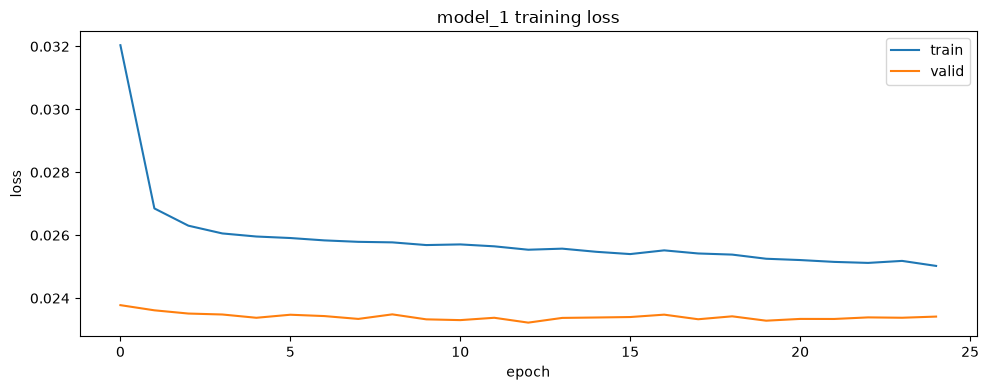

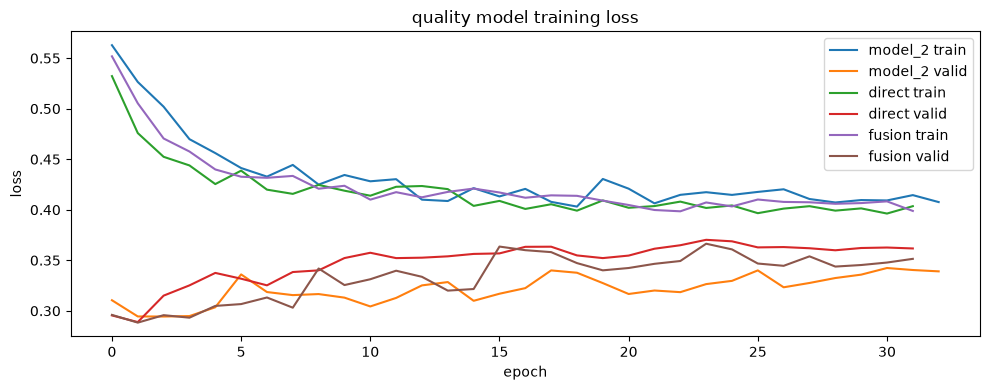

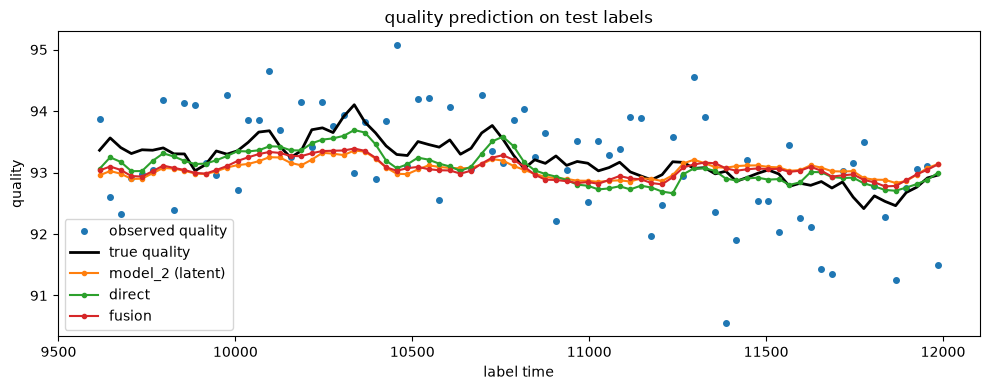

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history_1["train"], label="train")
plt.plot(history_1["val"], label="valid")
plt.title("model_1 training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_2["train"], label="model_2 train")
plt.plot(history_2["val"], label="model_2 valid")
plt.plot(history_direct["train"], label="direct train")
plt.plot(history_direct["val"], label="direct valid")
plt.plot(history_fusion["train"], label="fusion train")
plt.plot(history_fusion["val"], label="fusion valid")
plt.title("quality model training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(test_measurement_times, ytest, "o", markersize=4, label="observed quality")
plt.plot(test_measurement_times, true_at_test, "-", color="black", linewidth=2, label="true quality")
plt.plot(test_measurement_times, pred2, "o-", markersize=3, label="model_2 (latent)")
plt.plot(test_measurement_times, pred_direct, "o-", markersize=3, label="direct")
plt.plot(test_measurement_times, pred_fusion, "o-", markersize=3, label="fusion")
plt.title("quality prediction on test labels")
plt.xlabel("label time")
plt.ylabel("quality")
plt.legend()
plt.tight_layout()
plt.show()


## 16. 見やすくした

`model_2`(latent)と`direct_model` と `fusion_model` の比較。


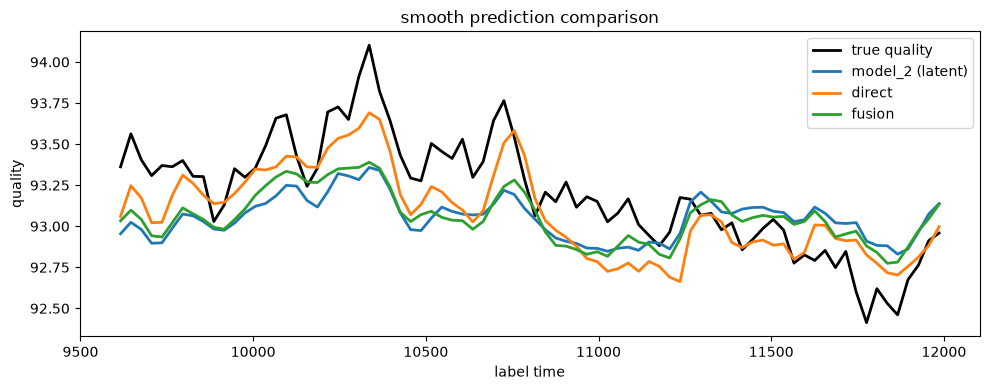

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(test_measurement_times, true_at_test, "-", color="black", linewidth=2, label="true quality")
plt.plot(test_measurement_times, pred2, "-", linewidth=2, label="model_2 (latent)")
plt.plot(test_measurement_times, pred_direct, "-", linewidth=2, label="direct")
plt.plot(test_measurement_times, pred_fusion, "-", linewidth=2, label="fusion")
plt.title("smooth prediction comparison")
plt.xlabel("label time")
plt.ylabel("quality")
plt.legend()
plt.tight_layout()
plt.show()


## 17. 色々

- 今のとこmodel_1をmodel_2に使う意味はあまりなさそう。
- 損失関数を新しく設計する。
- 頑健性を評価するために、ノイズの程度を強めたり、欠損率をあげるのがよさそう。
-